# Best-case Mohr–Coulomb versus BBFast comparison

This notebook compares the completed 102-series Mohr–Coulomb (MC) validation
runs with their equivalent best-physical-case Barton–Bandis/BBFast runs for
SW-T1, SW-T2, SW-S3, and SW-S4.

The comparison uses the campaign's authoritative Table-2 gate:

- eleven ordered injection stages;
- the stage-1 displacement datum;
- five independent observables: flow rate $Q$, effective normal stress
  $\sigma'_n$, shear stress $\tau$, normal displacement $d_n$, and shear
  displacement $d_s$;
- range-normalised RMSE (nRMSE) for each observable.

The 102 cases test whether carrying the latest selected scalar refinements onto
the audited 94-series MC transfer changes the constitutive comparison. They are
monotonic validation runs; cyclic and shut-in comparisons require separate
matched schedules.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts" / "table2_gate.py").is_file():
            return candidate
    raise FileNotFoundError("Could not locate scripts/table2_gate.py")


ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "scripts"))
import table2_gate  # noqa: E402

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
plt.rcParams.update({
    "figure.dpi": 115,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root: {ROOT}")

Project root: /media/geomechanics/Data4TB/projects/orca_4.0


## Matched cases

The BBFast column uses the nominal best physical case from the updated ranking.
The MC column uses the corresponding 102-series transfer. The old 94-series MC
case is retained only to determine whether the new scalar refinement materially
changed the baseline.

SW-S3 requires one qualification: BBFast `100_06` also sets normal unloading
retention to zero, while the MC material has no equivalent parameter. The
already-completed BBFast `99_06` case is therefore also scored below as the
strictest available one-block comparator; no additional SW-S3 run is needed.

In [2]:
PAIR_SPECS = {
    "SWT1": {
        "display": "SW-T1",
        "bb_case": "100_01_swt1_vm55um_ppfix",
        "bb_csv": "Examples/YeGhasemmi2018/SWT1/results_csv_hpc_rorqual/100_01_swt1_vm55um_ppfix_hpc.csv",
        "mc_case": "102_01_swt1_mc_vm55um_ppfix",
        "mc_csv": "Examples/YeGhasemmi2018/SWT1/results_csv_hpc_rorqual/102_01_swt1_mc_vm55um_ppfix_hpc.csv",
        "old_mc_case": "94_01_swt1_mc_final",
        "old_mc_csv": "Examples/YeGhasemmi2018/SWT1/results_csv_hpc_rorqual/94_01_swt1_mc_final_hpc.csv",
    },
    "SWT2": {
        "display": "SW-T2",
        "bb_case": "100_04_swt2_apscale0p0177_ppfix",
        "bb_csv": "Examples/YeGhasemmi2018/SWT2/results_csv_hpc_rorqual/100_04_swt2_apscale0p0177_ppfix_hpc.csv",
        "mc_case": "102_02_swt2_mc_apscale0p0177_ppfix",
        "mc_csv": "Examples/YeGhasemmi2018/SWT2/results_csv_hpc_rorqual/102_02_swt2_mc_apscale0p0177_ppfix_hpc.csv",
        "old_mc_case": "94_03_swt2_mc_final",
        "old_mc_csv": "Examples/YeGhasemmi2018/SWT2/results_csv_hpc_rorqual/94_03_swt2_mc_final_hpc.csv",
    },
    "SWS3": {
        "display": "SW-S3",
        "bb_case": "100_06_sw3_resc1p30_unld0p00_ppfix",
        "bb_csv": "Examples/YeGhasemmi2018/SWS3/results_csv_hpc_rorqual/100_06_sw3_resc1p30_unld0p00_ppfix_hpc.csv",
        "mc_case": "102_03_sw3_mc_resc1p30_ppfix",
        "mc_csv": "Examples/YeGhasemmi2018/SWS3/results_csv_hpc_rorqual/102_03_sw3_mc_resc1p30_ppfix_hpc.csv",
        "old_mc_case": "94_05_sw3_mc_final",
        "old_mc_csv": "Examples/YeGhasemmi2018/SWS3/results_csv_hpc_rorqual/94_05_sw3_mc_final_hpc.csv",
    },
    "SWS4": {
        "display": "SW-S4",
        "bb_case": "93_07_sw4_final_theta30_jrc5_ppfix",
        "bb_csv": "Examples/YeGhasemmi2018/SWS4/results_csv_hpc_rorqual/93_07_sw4_final_theta30_jrc5_ppfix_hpc.csv",
        "mc_case": "102_04_sw4_mc_theta30_jrc5_ppfix",
        "mc_csv": "Examples/YeGhasemmi2018/SWS4/results_csv_hpc_rorqual/102_04_sw4_mc_theta30_jrc5_ppfix_hpc.csv",
        "old_mc_case": "94_07_sw4_mc_final",
        "old_mc_csv": "Examples/YeGhasemmi2018/SWS4/results_csv_hpc_rorqual/94_07_sw4_mc_final_hpc.csv",
    },
}

for spec in PAIR_SPECS.values():
    for key in ("bb_csv", "mc_csv", "old_mc_csv"):
        path = ROOT / spec[key]
        if not path.is_file():
            raise FileNotFoundError(path)

pd.DataFrame([
    {
        "specimen": spec["display"],
        "best BBFast": spec["bb_case"],
        "MC 102": spec["mc_case"],
        "old MC control": spec["old_mc_case"],
    }
    for spec in PAIR_SPECS.values()
])

,specimen,best BBFast,MC 102,old MC control
0,SW-T1,100_01_swt1_vm55um_ppfix,102_01_swt1_mc_vm55um_ppfix,94_01_swt1_mc_final
1,SW-T2,100_04_swt2_apscale0p0177_ppfix,102_02_swt2_mc_apscale0p0177_ppfix,94_03_swt2_mc_final
2,SW-S3,100_06_sw3_resc1p30_unld0p00_ppfix,102_03_sw3_mc_resc1p30_ppfix,94_05_sw3_mc_final
3,SW-S4,93_07_sw4_final_theta30_jrc5_ppfix,102_04_sw4_mc_theta30_jrc5_ppfix,94_07_sw4_mc_final


## Result integrity

A result is accepted only if its time column is monotonic and unique, every
numeric value is finite, and the schedule scorer reaches all eleven Table-2
stages. These checks separate a completed but inaccurate model from a damaged
or truncated result file.

In [3]:
def score(path: str, sample: str) -> dict:
    return table2_gate.score_run(
        ROOT / path,
        sample,
        tag=None,
        tol_mpa=0.15,
        datum="stage1",
        preload_time=55.0,
    )


RESULTS = {}
health_rows = []
for sample, spec in PAIR_SPECS.items():
    RESULTS[sample] = {}
    for model, key in (("BBFast", "bb_csv"), ("MC 102", "mc_csv"), ("MC 94", "old_mc_csv")):
        path = ROOT / spec[key]
        raw = pd.read_csv(path, low_memory=False)
        numeric = raw.select_dtypes(include=[np.number]).to_numpy()
        result = score(spec[key], sample)
        RESULTS[sample][model] = result
        health_rows.append({
            "specimen": spec["display"],
            "model": model,
            "rows": len(raw),
            "end time (s)": float(raw["time"].iloc[-1]),
            "stages": f"{result['reached']}/11",
            "time monotonic": bool(raw["time"].is_monotonic_increasing),
            "duplicate times": int(raw["time"].duplicated().sum()),
            "non-finite numeric": int((~np.isfinite(numeric)).sum()),
        })

health = pd.DataFrame(health_rows)
display(health)
assert health["stages"].eq("11/11").all()
assert health["time monotonic"].all()
assert health["duplicate times"].eq(0).all()
assert health["non-finite numeric"].eq(0).all()
print("PASS: all paired and control results are complete and numerically well formed.")

,specimen,model,rows,end time (s),stages,time monotonic,duplicate times,non-finite numeric
0,SW-T1,BBFast,7523,3500.00,11/11,True,0,0
1,SW-T1,MC 102,7470,3500.00,11/11,True,0,0
2,SW-T1,MC 94,7471,3500.00,11/11,True,0,0
3,SW-T2,BBFast,3805,2852.53,11/11,True,0,0
4,SW-T2,MC 102,3807,2852.53,11/11,True,0,0
5,SW-T2,MC 94,3807,2852.53,11/11,True,0,0
6,SW-S3,BBFast,6404,4802.00,11/11,True,0,0
7,SW-S3,MC 102,6410,4802.00,11/11,True,0,0
8,SW-S3,MC 94,6413,4802.00,11/11,True,0,0
9,SW-S4,BBFast,2335,3500.00,11/11,True,0,0


PASS: all paired and control results are complete and numerically well formed.


## Headline accuracy comparison

The table below is the primary quantitative comparison. `BB reduction` is
$100(1-E_{BB}/E_{MC})$; positive values mean BBFast is more accurate. The
campaign treats changes smaller than 0.1 percentage points as unresolved
against the reproducibility floor.

In [4]:
headline_rows = []
observable_rows = []
for sample, spec in PAIR_SPECS.items():
    scores = {
        model: table2_gate.normalised_scores(result)
        for model, result in RESULTS[sample].items()
    }
    bb = scores["BBFast"]
    mc = scores["MC 102"]
    old = scores["MC 94"]
    headline_rows.append({
        "specimen": spec["display"],
        "BBFast mean nRMSE (%)": bb["mean"],
        "MC 102 mean nRMSE (%)": mc["mean"],
        "old MC 94 mean nRMSE (%)": old["mean"],
        "MC change, 102−94 (pp)": mc["mean"] - old["mean"],
        "MC/BB error ratio": mc["mean"] / bb["mean"],
        "BB reduction relative to MC (%)": 100.0 * (1.0 - bb["mean"] / mc["mean"]),
    })
    for observable in table2_gate.SCORED:
        observable_rows.append({
            "specimen": spec["display"],
            "observable": observable,
            "BBFast nRMSE (%)": bb[observable],
            "MC nRMSE (%)": mc[observable],
            "BB reduction relative to MC (%)": 100.0 * (1.0 - bb[observable] / mc[observable]),
            "better model": "BBFast" if bb[observable] < mc[observable] else "MC",
        })

headline = pd.DataFrame(headline_rows)
observable_scores = pd.DataFrame(observable_rows)
display(headline.style.format(precision=3))

bb_mean = headline["BBFast mean nRMSE (%)"].mean()
mc_mean = headline["MC 102 mean nRMSE (%)"].mean()
overall_reduction = 100.0 * (1.0 - bb_mean / mc_mean)
print(f"Four-specimen mean: BBFast = {bb_mean:.3f}%, MC = {mc_mean:.3f}%")
print(f"MC carries {mc_mean / bb_mean:.2f}× the BBFast error.")
print(f"BBFast reduces mean error by {overall_reduction:.1f}% relative to MC.")

,specimen,BBFast mean nRMSE (%),MC 102 mean nRMSE (%),old MC 94 mean nRMSE (%),"MC change, 102−94 (pp)",MC/BB error ratio,BB reduction relative to MC (%)
0,SW-T1,2.689,25.351,25.272,0.078,9.429,89.394
1,SW-T2,2.132,23.365,23.144,0.220,10.960,90.876
2,SW-S3,4.354,18.744,18.470,0.273,4.305,76.772
3,SW-S4,6.139,8.969,8.973,-0.004,1.461,31.548


Four-specimen mean: BBFast = 3.828%, MC = 19.107%
MC carries 4.99× the BBFast error.
BBFast reduces mean error by 80.0% relative to MC.


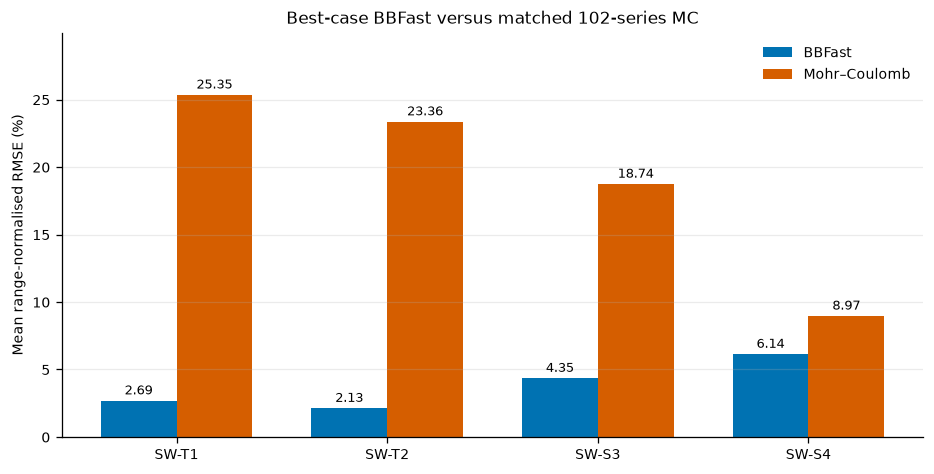

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
x = np.arange(len(headline))
width = 0.36
bb_values = headline["BBFast mean nRMSE (%)"].to_numpy()
mc_values = headline["MC 102 mean nRMSE (%)"].to_numpy()

bb_bars = ax.bar(x - width / 2, bb_values, width, label="BBFast", color="#0072B2")
mc_bars = ax.bar(x + width / 2, mc_values, width, label="Mohr–Coulomb", color="#D55E00")
ax.bar_label(bb_bars, fmt="%.2f", padding=2, fontsize=8)
ax.bar_label(mc_bars, fmt="%.2f", padding=2, fontsize=8)
ax.set_xticks(x, headline["specimen"])
ax.set_ylabel("Mean range-normalised RMSE (%)")
ax.set_title("Best-case BBFast versus matched 102-series MC")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
ax.set_ylim(0, max(mc_values) * 1.18)
plt.tight_layout()
plt.show()

### Interpretation

The updated scalar refinements do not rescue the MC baseline. Relative to the
old 94-series MC results, SW-T1 changes by +0.078 percentage points and SW-S4
by −0.004 points, both below the 0.1-point reproducibility floor. The resolved
changes on SW-T2 (+0.220 points) and SW-S3 (+0.273 points) make MC slightly
worse. A further monotonic scalar-tuning run is therefore not justified.

Across the selected pairs, BBFast reduces the four-specimen mean nRMSE from
19.107% to 3.828%, an 80.0% reduction. The improvement is largest on the two
tensile fractures and smallest on the progressive SW-S4 saw-cut response.

## Per-observable comparison

The constitutive conclusion should not rest only on an average. The next table
shows every specimen–observable combination separately.

In [6]:
observable_pivot = observable_scores.pivot(
    index=["specimen", "observable"],
    columns="better model",
    values="BB reduction relative to MC (%)",
)
display(observable_scores.style.format({
    "BBFast nRMSE (%)": "{:.3f}",
    "MC nRMSE (%)": "{:.3f}",
    "BB reduction relative to MC (%)": "{:+.1f}",
}))

counts = observable_scores["better model"].value_counts()
print(f"BBFast is better in {counts.get('BBFast', 0)}/20 scored specimen-observable pairs.")
print(f"MC is better in {counts.get('MC', 0)}/20 pairs.")

,specimen,observable,BBFast nRMSE (%),MC nRMSE (%),BB reduction relative to MC (%),better model
0,SW-T1,Q_ml_min,4.511,22.990,+80.4,BBFast
1,SW-T1,sigma_n_MPa,1.440,18.661,+92.3,BBFast
2,SW-T1,tau_MPa,1.978,25.834,+92.3,BBFast
3,SW-T1,dn_mm,4.584,31.317,+85.4,BBFast
4,SW-T1,ds_mm,0.930,27.951,+96.7,BBFast
5,SW-T2,Q_ml_min,4.336,15.649,+72.3,BBFast
6,SW-T2,sigma_n_MPa,1.274,19.318,+93.4,BBFast
7,SW-T2,tau_MPa,1.723,26.174,+93.4,BBFast
8,SW-T2,dn_mm,2.067,27.852,+92.6,BBFast
9,SW-T2,ds_mm,1.260,27.831,+95.5,BBFast


BBFast is better in 19/20 scored specimen-observable pairs.
MC is better in 1/20 pairs.


The sole exception is SW-S4 shear slip: MC gives 6.178% nRMSE and BBFast
7.082%. BBFast remains better for SW-S4 flow, effective normal stress, shear
stress, and especially normal dilation. Consequently, the paper should say
**19 of 20 channels improve**, not that every channel improves.

## Where the trajectories separate

The panels retain the eleven ordered stages rather than reducing each curve to
one score. Stage 6 is the peak-pressure hold; stages 7–11 are unloading.

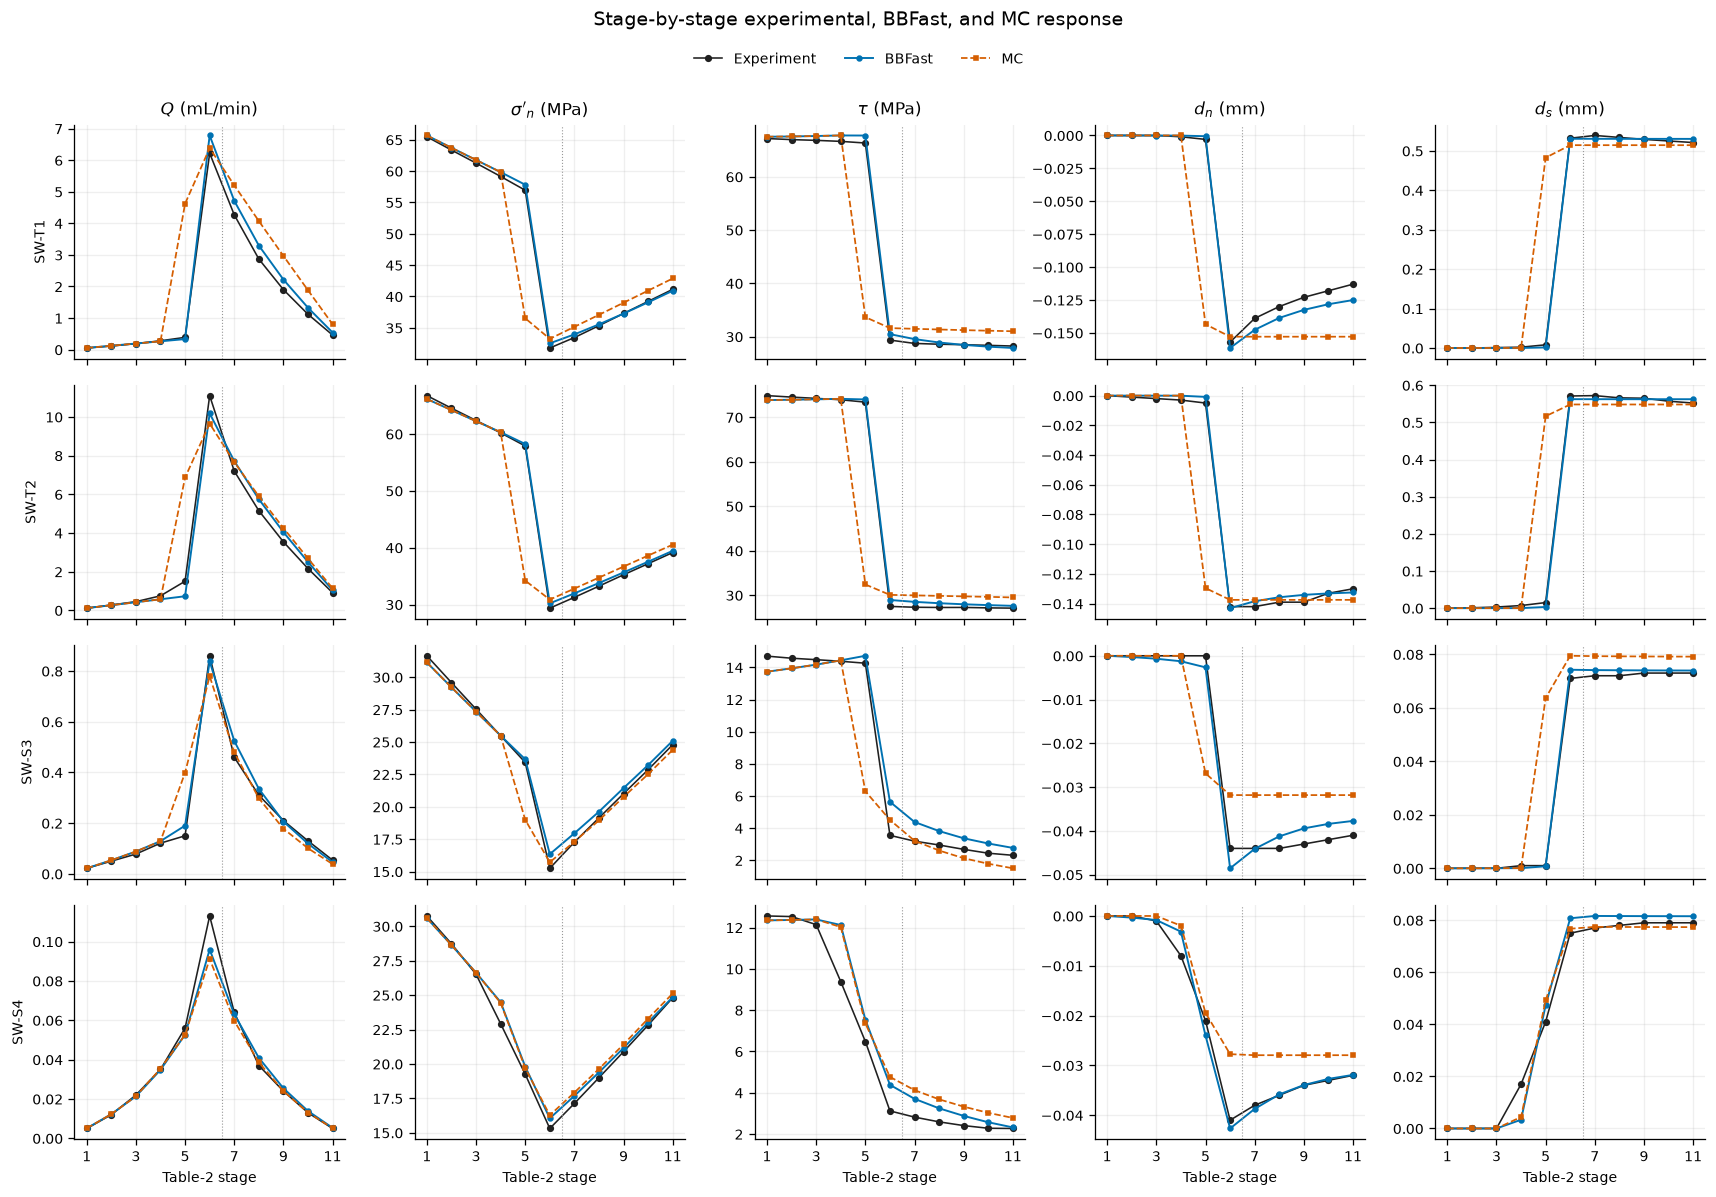

In [7]:
PLOT_KEYS = [
    ("Q_ml_min", "$Q$ (mL/min)"),
    ("sigma_n_MPa", "$\\sigma'_n$ (MPa)"),
    ("tau_MPa", "$\\tau$ (MPa)"),
    ("dn_mm", "$d_n$ (mm)"),
    ("ds_mm", "$d_s$ (mm)"),
]

fig, axes = plt.subplots(4, 5, figsize=(15, 10), sharex=True, squeeze=False)
for row, (sample, spec) in enumerate(PAIR_SPECS.items()):
    bb = RESULTS[sample]["BBFast"]["table"]
    mc = RESULTS[sample]["MC 102"]["table"]
    stage = bb["stage"].to_numpy()
    for col, (key, label) in enumerate(PLOT_KEYS):
        ax = axes[row, col]
        ax.plot(stage, bb[f"{key}_paper"], "o-", color="#202020", ms=3.5, lw=1.0, label="Experiment")
        ax.plot(stage, bb[f"{key}_model"], "o-", color="#0072B2", ms=3.0, lw=1.2, label="BBFast")
        ax.plot(stage, mc[f"{key}_model"], "s--", color="#D55E00", ms=3.0, lw=1.1, label="MC")
        ax.axvline(6.5, color="#999999", lw=0.7, ls=":")
        ax.grid(alpha=0.2)
        if row == 0:
            ax.set_title(label)
        if col == 0:
            ax.set_ylabel(spec["display"])
        if row == 3:
            ax.set_xlabel("Table-2 stage")
            ax.set_xticks(range(1, 12, 2))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Stage-by-stage experimental, BBFast, and MC response", y=1.035, fontsize=12)
plt.tight_layout()
plt.show()

### Premature weakening in MC

For SW-T1, SW-T2, and SW-S3, the decisive separation occurs at loading stage 5,
one pressure stage before the experimental peak event. MC has already generated
most of its final shear displacement, while the experiment and BBFast remain
nearly stuck. The stage-6 endpoints can look reasonable again, but the path
between stages 4 and 6 is incorrect.

In [8]:
stage5_rows = []
for sample, spec in PAIR_SPECS.items():
    bb = RESULTS[sample]["BBFast"]["table"].iloc[4]
    mc = RESULTS[sample]["MC 102"]["table"].iloc[4]
    stage5_rows.append({
        "specimen": spec["display"],
        "pressure target (MPa)": mc["Pi_target_MPa"],
        "experimental ds (mm)": mc["ds_mm_paper"],
        "BBFast ds (mm)": bb["ds_mm_model"],
        "MC ds (mm)": mc["ds_mm_model"],
        "experimental tau (MPa)": mc["tau_MPa_paper"],
        "BBFast tau (MPa)": bb["tau_MPa_model"],
        "MC tau (MPa)": mc["tau_MPa_model"],
    })

stage5 = pd.DataFrame(stage5_rows)
display(stage5.style.format(precision=3))

,specimen,pressure target (MPa),experimental ds (mm),BBFast ds (mm),MC ds (mm),experimental tau (MPa),BBFast tau (MPa),MC tau (MPa)
0,SW-T1,24,0.008,0.001,0.483,66.320,67.726,33.649
1,SW-T2,24,0.015,0.003,0.517,73.400,74.009,32.410
2,SW-S3,24,0.001,0.001,0.064,14.260,14.722,6.292
3,SW-S4,24,0.041,0.047,0.049,6.480,7.540,7.361


This is a constitutive-path discrepancy rather than a failed simulation. The
linear MC transfer is matched to BBFast at onset, but its single evolving
roughness state cannot reproduce the separate peak-to-residual strength and
dilation histories carried by BBFast. Closure and aperture-scale adjustments
change the hydraulic response but do not move the premature MC weakening onto
the measured stage.

SW-S4 behaves differently: slip develops progressively, and MC follows shear
displacement slightly better. Its normal-dilation trajectory remains much
worse, so the specimen still favours BBFast in the combined score.

## SW-S3 strict-match sensitivity

The headline comparison uses the nominal best BBFast result, `100_06`, even
though its zero unloading-retention mechanism has no MC counterpart. For a
strictest-available constitutive comparison, use the existing `99_06` BBFast
result, which shares the 1.30 MPa residual cohesion without that extra best-case
unloading refinement.

In [9]:
sws3_strict_path = (
    "Examples/YeGhasemmi2018/SWS3/results_csv_hpc_rorqual/"
    "99_06_sw3_resc1p30_ppfix_hpc.csv"
)
sws3_strict = table2_gate.normalised_scores(score(sws3_strict_path, "SWS3"))
sws3_best = table2_gate.normalised_scores(RESULTS["SWS3"]["BBFast"])
sws3_mc = table2_gate.normalised_scores(RESULTS["SWS3"]["MC 102"])

pd.DataFrame([
    {"comparison role": "nominal best BBFast", "case": "100_06", "mean nRMSE (%)": sws3_best["mean"]},
    {"comparison role": "strictest available BBFast match", "case": "99_06", "mean nRMSE (%)": sws3_strict["mean"]},
    {"comparison role": "MC", "case": "102_03", "mean nRMSE (%)": sws3_mc["mean"]},
]).style.format({"mean nRMSE (%)": "{:.3f}"})

,comparison role,case,mean nRMSE (%)
0,nominal best BBFast,100_06,4.354
1,strictest available BBFast match,99_06,4.451
2,MC,102_03,18.744


The SW-S3 conclusion is insensitive to this choice: BBFast scores 4.354% using
the nominal best case or 4.451% using the strict comparator, versus 18.744% for
MC. The existing result therefore resolves the caveat without a new run.

## Detailed stage tables

These tables preserve the numerical values used in every plotted trajectory.
Displacements are expressed relative to stage 1, matching the campaign score.

In [10]:
for sample, spec in PAIR_SPECS.items():
    bb = RESULTS[sample]["BBFast"]["table"]
    mc = RESULTS[sample]["MC 102"]["table"]
    detail = pd.DataFrame({
        "stage": bb["stage"],
        "branch": bb["segment"],
        "Pi target (MPa)": bb["Pi_target_MPa"],
    })
    for key, short in (
        ("Q_ml_min", "Q"),
        ("sigma_n_MPa", "sigma_n"),
        ("tau_MPa", "tau"),
        ("dn_mm", "dn"),
        ("ds_mm", "ds"),
    ):
        detail[f"{short} experiment"] = bb[f"{key}_paper"]
        detail[f"{short} BBFast"] = bb[f"{key}_model"]
        detail[f"{short} MC"] = mc[f"{key}_model"]
    print(spec["display"])
    display(detail.style.format(precision=4))

SW-T1


,stage,branch,Pi target (MPa),Q experiment,Q BBFast,Q MC,sigma_n experiment,sigma_n BBFast,sigma_n MC,tau experiment,tau BBFast,tau MC,dn experiment,dn BBFast,dn MC,ds experiment,ds BBFast,ds MC
0,1,loading,8,0.0530,0.0528,0.0528,65.4700,65.6757,65.6757,67.1600,67.4952,67.4952,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2,loading,12,0.1140,0.1232,0.1232,63.3500,63.7101,63.7101,66.9600,67.5502,67.5502,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000
2,3,loading,16,0.1900,0.1936,0.1936,61.2700,61.7644,61.7644,66.8200,67.6372,67.6372,0.0000,-0.0001,0.0000,0.0010,0.0000,0.0000
3,4,loading,20,0.2800,0.2640,0.2640,59.1400,59.8291,59.8289,66.6300,67.7408,67.7404,-0.0010,-0.0001,0.0000,0.0020,0.0001,0.0000
4,5,loading,24,0.3890,0.3344,4.6228,56.9400,57.8198,36.5265,66.3200,67.7258,33.6495,-0.0030,-0.0006,-0.1435,0.0080,0.0014,0.4826
5,6,loading,28,6.2200,6.7831,6.3816,31.7900,32.5331,33.2429,29.3500,30.4593,31.5953,-0.1570,-0.1615,-0.1529,0.5320,0.5306,0.5144
6,7,unloading,24,4.2700,4.7138,5.2054,33.4500,33.9533,35.1594,28.7200,29.5315,31.4616,-0.1390,-0.1477,-0.1529,0.5390,0.5305,0.5144
7,8,unloading,20,2.8700,3.2974,4.0733,35.3500,35.5546,37.0788,28.5700,28.8934,31.3327,-0.1300,-0.1386,-0.1529,0.5340,0.5304,0.5144
8,9,unloading,16,1.9000,2.2193,2.9684,37.2900,37.2735,39.0053,28.4800,28.4435,31.2150,-0.1230,-0.1325,-0.1529,0.5290,0.5304,0.5143
9,10,unloading,12,1.1200,1.3265,1.8806,39.2200,39.0682,40.9374,28.3600,28.1150,31.1064,-0.1180,-0.1282,-0.1529,0.5250,0.5303,0.5143


SW-T2


,stage,branch,Pi target (MPa),Q experiment,Q BBFast,Q MC,sigma_n experiment,sigma_n BBFast,sigma_n MC,tau experiment,tau BBFast,tau MC,dn experiment,dn BBFast,dn MC,ds experiment,ds BBFast,ds MC
0,1,loading,8,0.1150,0.1144,0.1144,66.7400,66.1436,66.1436,74.8700,73.8609,73.8609,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2,loading,12,0.2760,0.2670,0.2670,64.5300,64.1929,64.1929,74.5400,73.9462,73.9463,-0.0010,-0.0000,0.0000,0.0010,0.0000,0.0000
2,3,loading,16,0.4500,0.4199,0.4199,62.3700,62.2464,62.2465,74.2500,74.0390,74.0391,-0.0020,-0.0000,0.0000,0.0030,0.0000,0.0000
3,4,loading,20,0.7500,0.5731,0.5731,60.1900,60.3061,60.3046,73.9400,74.1423,74.1397,-0.0030,-0.0001,-0.0000,0.0070,0.0000,0.0000
4,5,loading,24,1.5050,0.7296,6.8686,57.8800,58.2294,34.2119,73.4000,74.0094,32.4100,-0.0050,-0.0008,-0.1295,0.0150,0.0031,0.5166
5,6,loading,28,11.1000,10.1795,9.6527,29.3600,30.2001,30.8619,27.4800,28.9255,30.0716,-0.1420,-0.1430,-0.1374,0.5710,0.5624,0.5482
6,7,unloading,24,7.2000,7.7187,7.6624,31.2600,31.9560,32.7981,27.2900,28.5027,29.9612,-0.1420,-0.1384,-0.1374,0.5720,0.5624,0.5482
7,8,unloading,20,5.1500,5.7476,5.8981,33.2300,33.7795,34.7320,27.2400,28.1970,29.8467,-0.1390,-0.1357,-0.1374,0.5660,0.5624,0.5482
8,9,unloading,16,3.5400,4.0449,4.2563,35.2300,35.6428,36.6683,27.2500,27.9601,29.7363,-0.1390,-0.1341,-0.1374,0.5650,0.5623,0.5482
9,10,unloading,12,2.1600,2.4981,2.6805,37.1800,37.5316,38.6070,27.1500,27.7675,29.6301,-0.1330,-0.1331,-0.1374,0.5570,0.5623,0.5481


SW-S3


,stage,branch,Pi target (MPa),Q experiment,Q BBFast,Q MC,sigma_n experiment,sigma_n BBFast,sigma_n MC,tau experiment,tau BBFast,tau MC,dn experiment,dn BBFast,dn MC,ds experiment,ds BBFast,ds MC
0,1,loading,8,0.0220,0.0218,0.0218,31.6500,31.1360,31.1360,14.7000,13.7310,13.7310,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2,loading,12,0.0500,0.0535,0.0535,29.5800,29.2181,29.2181,14.5700,13.9414,13.9414,0.0000,-0.0003,0.0000,0.0000,0.0000,0.0000
2,3,loading,16,0.0780,0.0881,0.0881,27.5300,27.3413,27.3413,14.4800,14.1706,14.1706,0.0000,-0.0007,0.0000,0.0000,0.0000,0.0000
3,4,loading,20,0.1210,0.1289,0.1289,25.4800,25.4871,25.4871,14.3800,14.4381,14.4381,0.0000,-0.0013,0.0000,0.0010,0.0001,0.0001
4,5,loading,24,0.1500,0.1901,0.3992,23.4200,23.6636,18.9909,14.2600,14.7216,6.2921,0.0000,-0.0026,-0.0269,0.0010,0.0008,0.0637
5,6,loading,28,0.8600,0.8380,0.7795,15.2500,16.3420,15.7167,3.5500,5.6376,4.5095,-0.0440,-0.0485,-0.0318,0.0710,0.0742,0.0795
6,7,unloading,24,0.4600,0.5242,0.4793,17.2700,17.9538,17.3063,3.1900,4.3817,3.2130,-0.0440,-0.0441,-0.0318,0.0720,0.0741,0.0793
7,8,unloading,20,0.3100,0.3354,0.2980,19.1400,19.6213,18.9506,2.9500,3.8164,2.6063,-0.0440,-0.0412,-0.0318,0.0720,0.0741,0.0793
8,9,unloading,16,0.2100,0.2062,0.1781,21.0100,21.4418,20.7533,2.6800,3.3689,2.1275,-0.0430,-0.0394,-0.0318,0.0730,0.0740,0.0792
9,10,unloading,12,0.1300,0.1190,0.1008,22.8600,23.2165,22.5185,2.4400,3.0442,1.7854,-0.0420,-0.0384,-0.0318,0.0730,0.0740,0.0792


SW-S4


,stage,branch,Pi target (MPa),Q experiment,Q BBFast,Q MC,sigma_n experiment,sigma_n BBFast,sigma_n MC,tau experiment,tau BBFast,tau MC,dn experiment,dn BBFast,dn MC,ds experiment,ds BBFast,ds MC
0,1,loading,8,0.0050,0.0051,0.0051,30.7500,30.5948,30.5948,12.5600,12.3457,12.3457,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2,loading,12,0.0120,0.0123,0.0123,28.7300,28.6321,28.6321,12.5300,12.3664,12.3664,0.0000,-0.0003,0.0000,0.0000,0.0000,0.0000
2,3,loading,16,0.0220,0.0213,0.0213,26.5100,26.6242,26.6242,12.1400,12.3917,12.3917,-0.0010,-0.0008,0.0000,0.0000,0.0000,0.0000
3,4,loading,20,0.0350,0.0348,0.0354,22.9200,24.4893,24.4319,9.3800,12.1212,12.0217,-0.0080,-0.0031,-0.0020,0.0170,0.0034,0.0044
4,5,loading,24,0.0560,0.0527,0.0526,19.2500,19.8036,19.7000,6.4800,7.5400,7.3606,-0.0210,-0.0240,-0.0194,0.0410,0.0473,0.0493
5,6,loading,28,0.1130,0.0959,0.0912,15.3100,16.0484,16.2703,3.1200,4.3827,4.7672,-0.0410,-0.0427,-0.0277,0.0750,0.0807,0.0767
6,7,unloading,24,0.0640,0.0631,0.0597,17.1300,17.6795,17.9219,2.8200,3.7053,4.1251,-0.0380,-0.0387,-0.0280,0.0770,0.0816,0.0774
7,8,unloading,20,0.0370,0.0409,0.0386,19.0000,19.3879,19.6397,2.5900,3.2449,3.6809,-0.0360,-0.0358,-0.0280,0.0780,0.0816,0.0774
8,9,unloading,16,0.0240,0.0254,0.0240,20.8900,21.1601,21.4187,2.4100,2.8794,3.3273,-0.0340,-0.0339,-0.0280,0.0790,0.0816,0.0774
9,10,unloading,12,0.0130,0.0139,0.0131,22.8200,23.0291,23.2923,2.2800,2.5707,3.0266,-0.0330,-0.0327,-0.0280,0.0790,0.0815,0.0774


## Conclusions for the paper

1. All four 102-series MC simulations are complete and scoreable; their poor
   agreement is not caused by truncation or damaged output.
2. For the updated best-case pairs, BBFast lowers the four-specimen mean nRMSE
   from **19.107% to 3.828%**, an **80.0% reduction**.
3. BBFast is more accurate in **19 of 20** specimen–observable comparisons.
   The exception is SW-S4 shear displacement, where MC is modestly better.
4. The large SW-T1, SW-T2, and SW-S3 error is created by premature MC
   weakening at loading stage 5, not by the final post-slip endpoint alone.
5. The 102 refinements do not support another monotonic MC tuning run. The
   model discrepancy lies in the weakening/dilation path that the comparison
   is intended to test.
6. These results complete the **monotonic** comparison only. A direct
   MC-versus-BBFast cyclic or shut-in claim requires matched MC versions of the
   101-series schedules and should not be inferred from this notebook.